Cose da fare: visualizzazione immagini dopo conversione a dataset, cerco problema scale e poi faccio rete. Devo provare a levare ultima batchnorm e ridurre i parametri ancora di più

In [ ]:
from google.colab import drive
try:
  import awkward as ak
except:
  !pip install awkward
  import awkward as ak
import os
import numpy as np
import matplotlib.pyplot as plt


drive.mount('/content/drive')

voxel_directory = "/content/drive/MyDrive/dataset_voxel.npy"
voxel_directory1 = "/content/drive/MyDrive/dataset_voxel1.npy"
voxel_directory2 = "/content/drive/MyDrive/dataset_voxel2.npy"
target_energy_directory = "/content/drive/MyDrive/target_energy.npy"
target_energy_directory1 = "/content/drive/MyDrive/target_energy1.npy"
target_energy_directory2  = "/content/drive/MyDrive/target_energy2.npy"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 39.9 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
dataset0 = np.load(voxel_directory)
target_energy0 = np.load(target_energy_directory)
dataset1 = np.load(voxel_directory1)
target_energy1 = np.load(target_energy_directory1)
dataset2 = np.load(voxel_directory2)
target_energy2 = np.load(target_energy_directory2)
dataset = np.concatenate((dataset0, dataset1, dataset2), axis=0)
target_energy = np.concatenate((target_energy0, target_energy1, target_energy2), axis=0)
print(dataset.shape)
print(target_energy.shape)


(300000, 28, 15, 15)
(300000,)


In [ ]:
dataset.shape

(300000, 28, 15, 15)

In [ ]:
def plot_all_layers_after_transf(dataset, event):
    if isinstance(event, int):
        events_list = [event]
    else:
        events_list = event
    for elem in events_list:
        evento_singolo = dataset[elem]
        fig, axes = plt.subplots(7, 4, figsize=(15, 20))
        fig.suptitle(f'Event: {elem} - Longitudinal Profile (28 Layer)', fontsize=16)
        axes = axes.flatten()
        vmax = evento_singolo.max()

        for j in range(28):
            ax = axes[j]
            im = ax.imshow(evento_singolo[j, :, :], cmap='viridis', vmin=0, vmax=vmax)
            ax.set_title(f'Layer {j}', fontsize=8)
            ax.axis('off')
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
        fig.colorbar(im, cax=cbar_ax, label='Energy')

        plt.show()



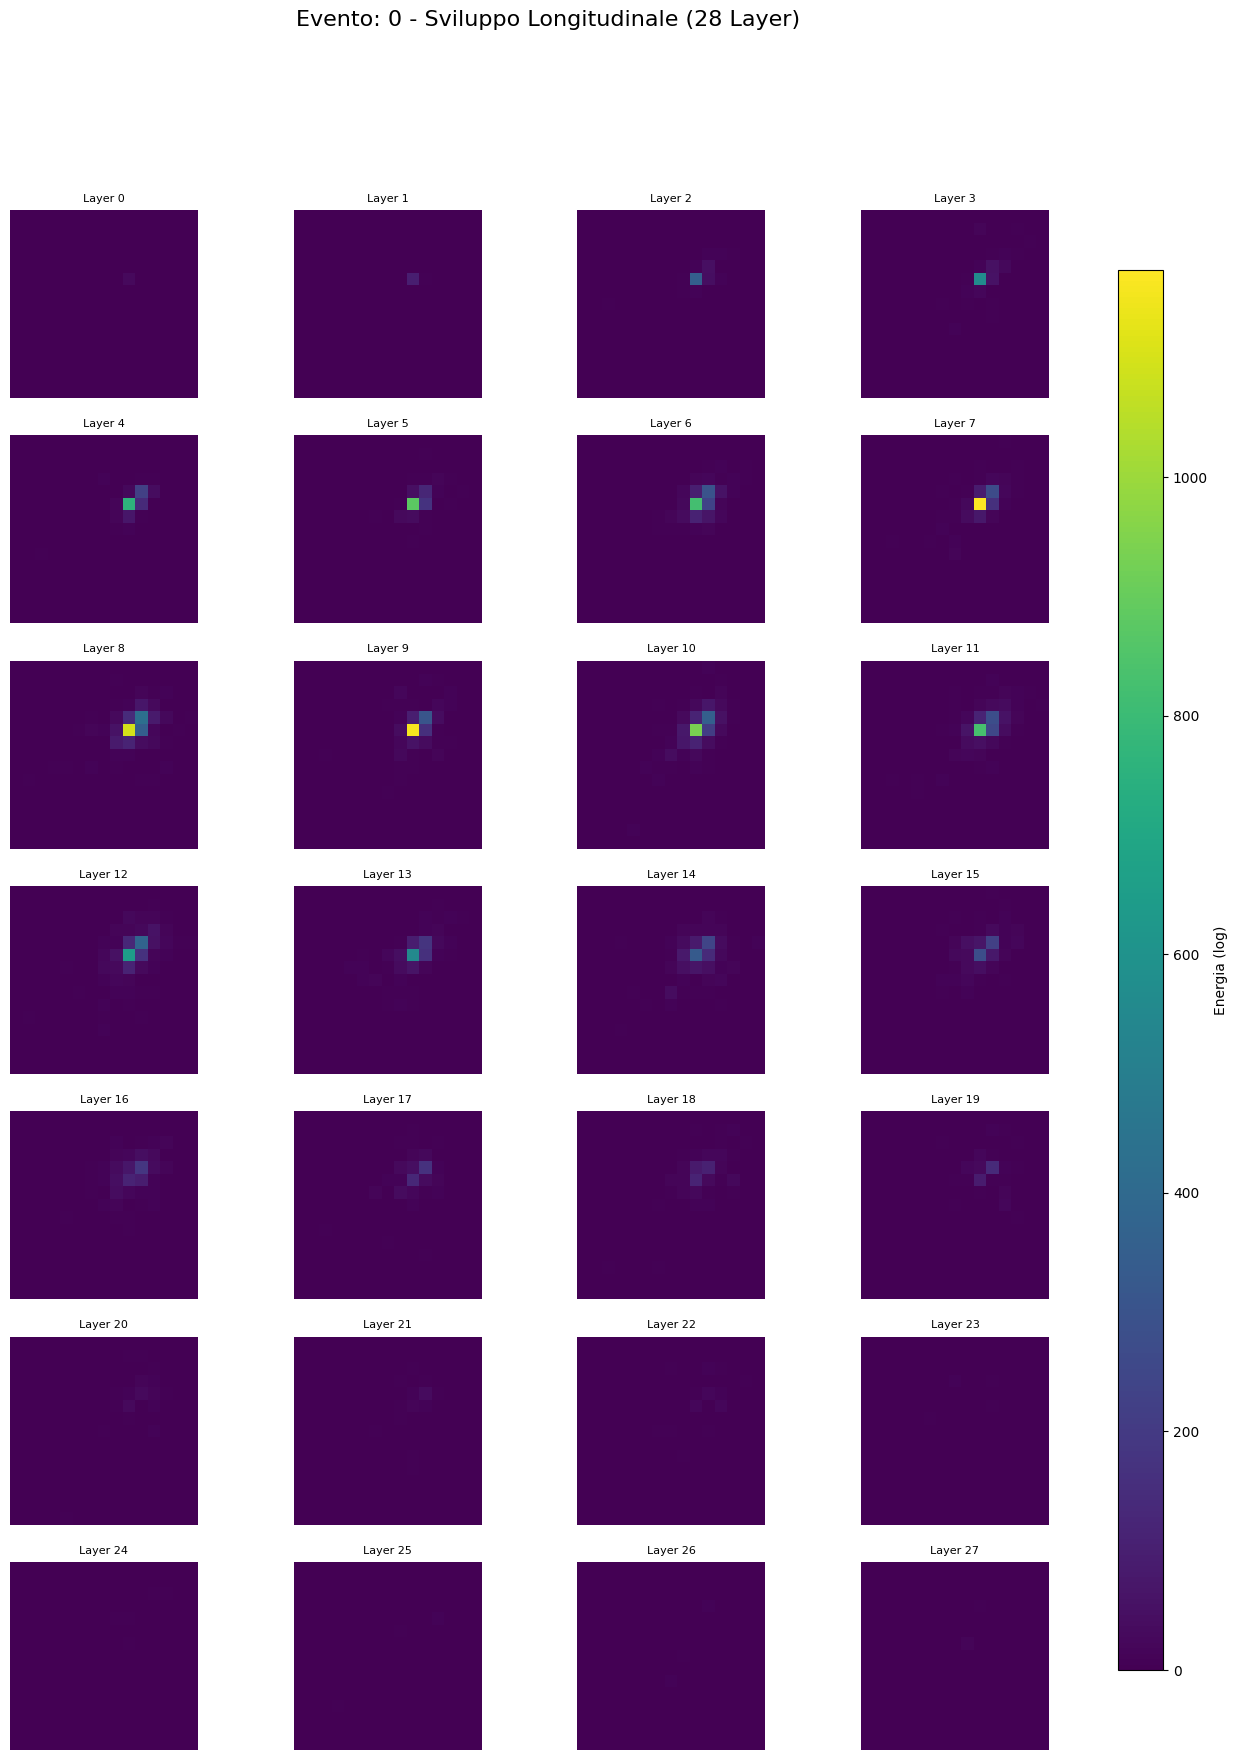

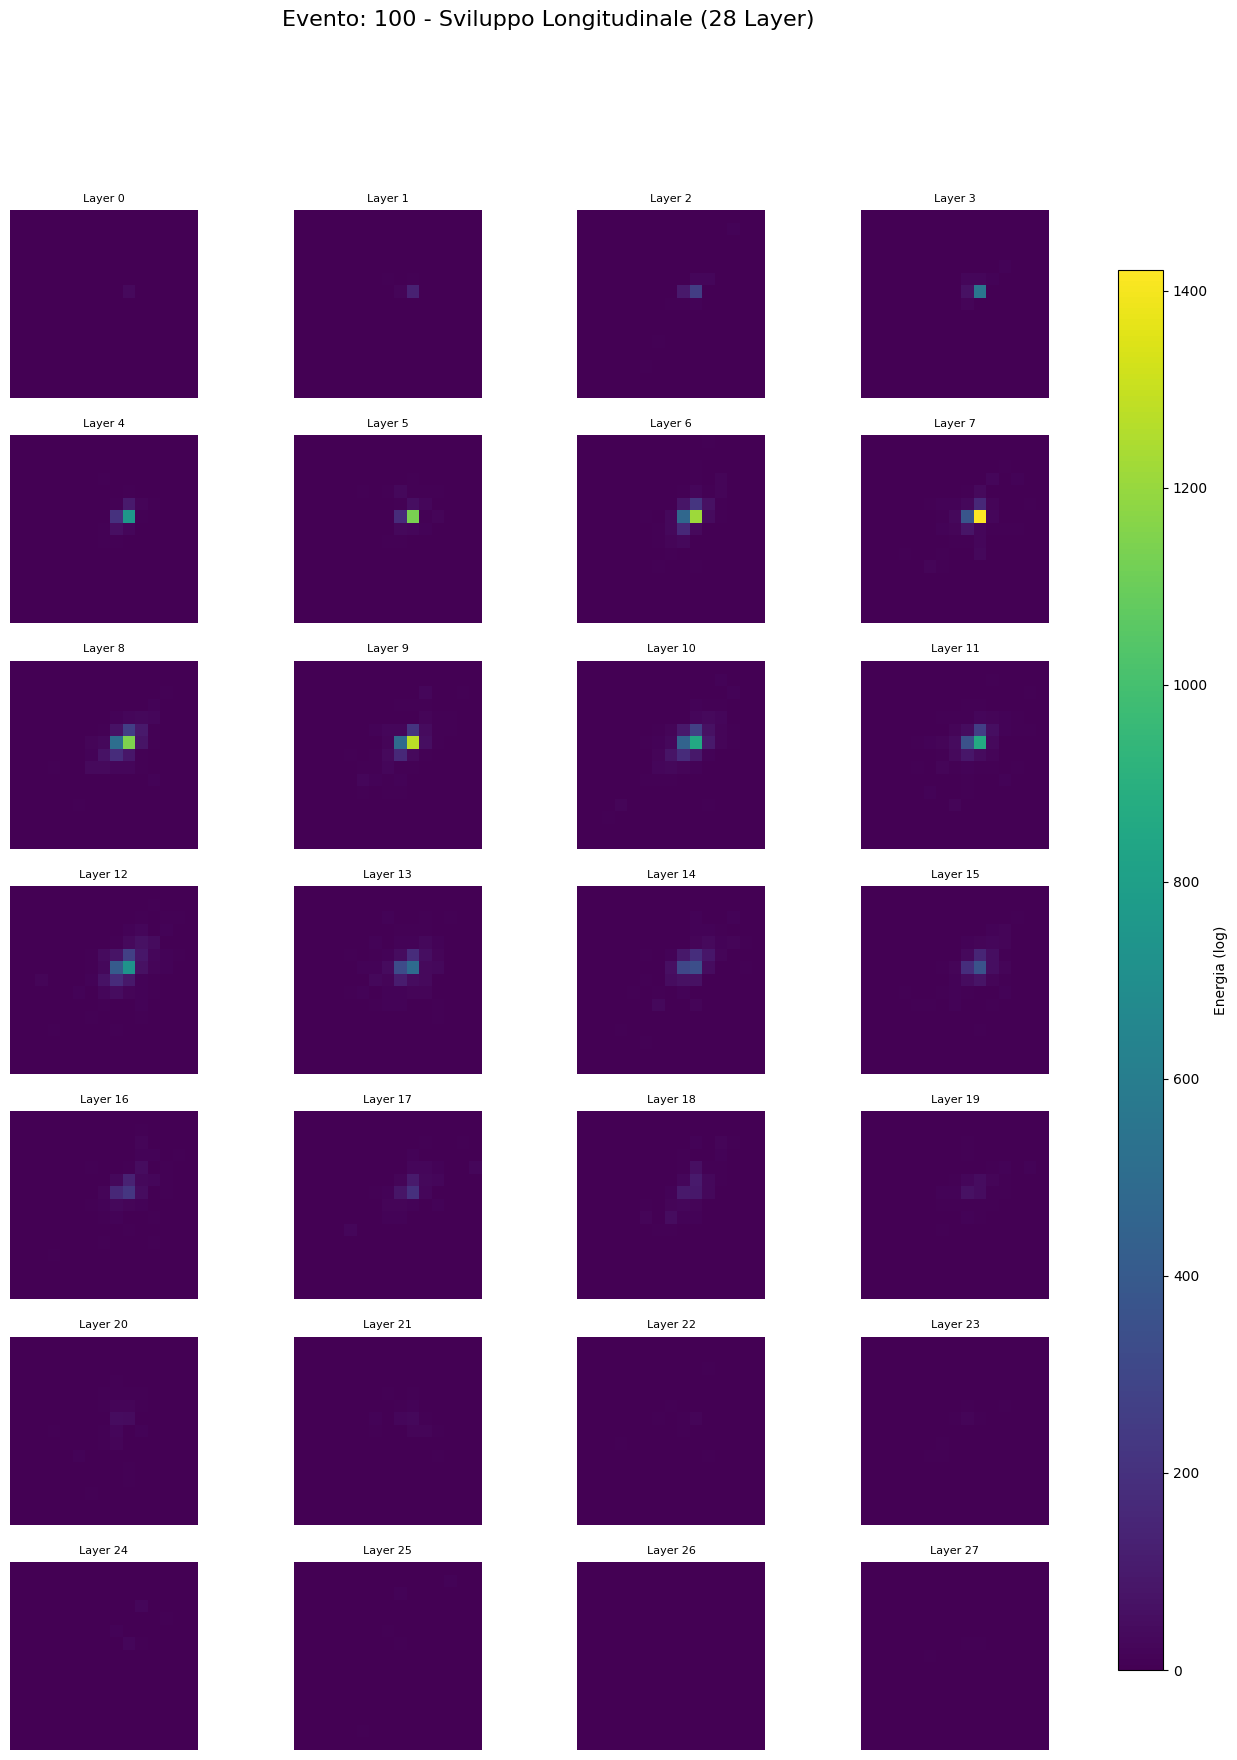

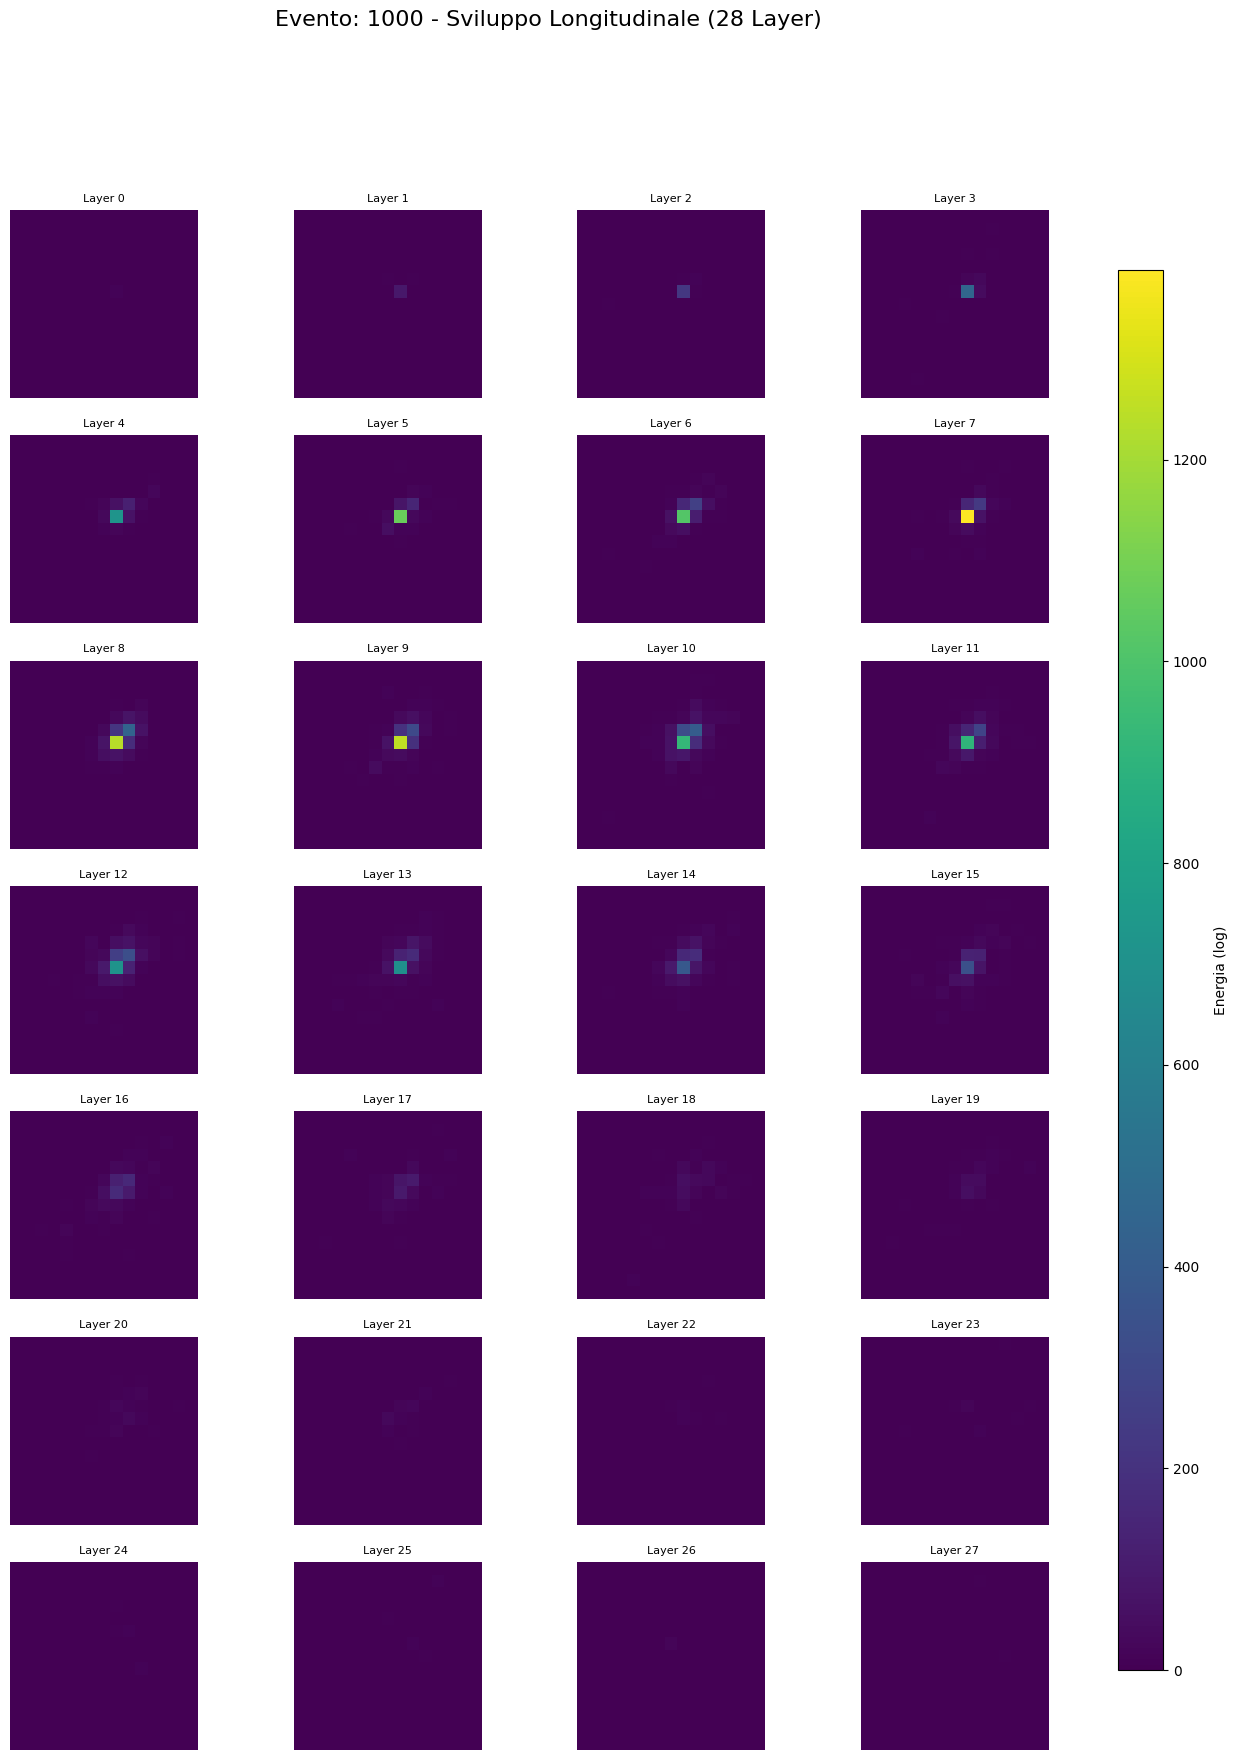

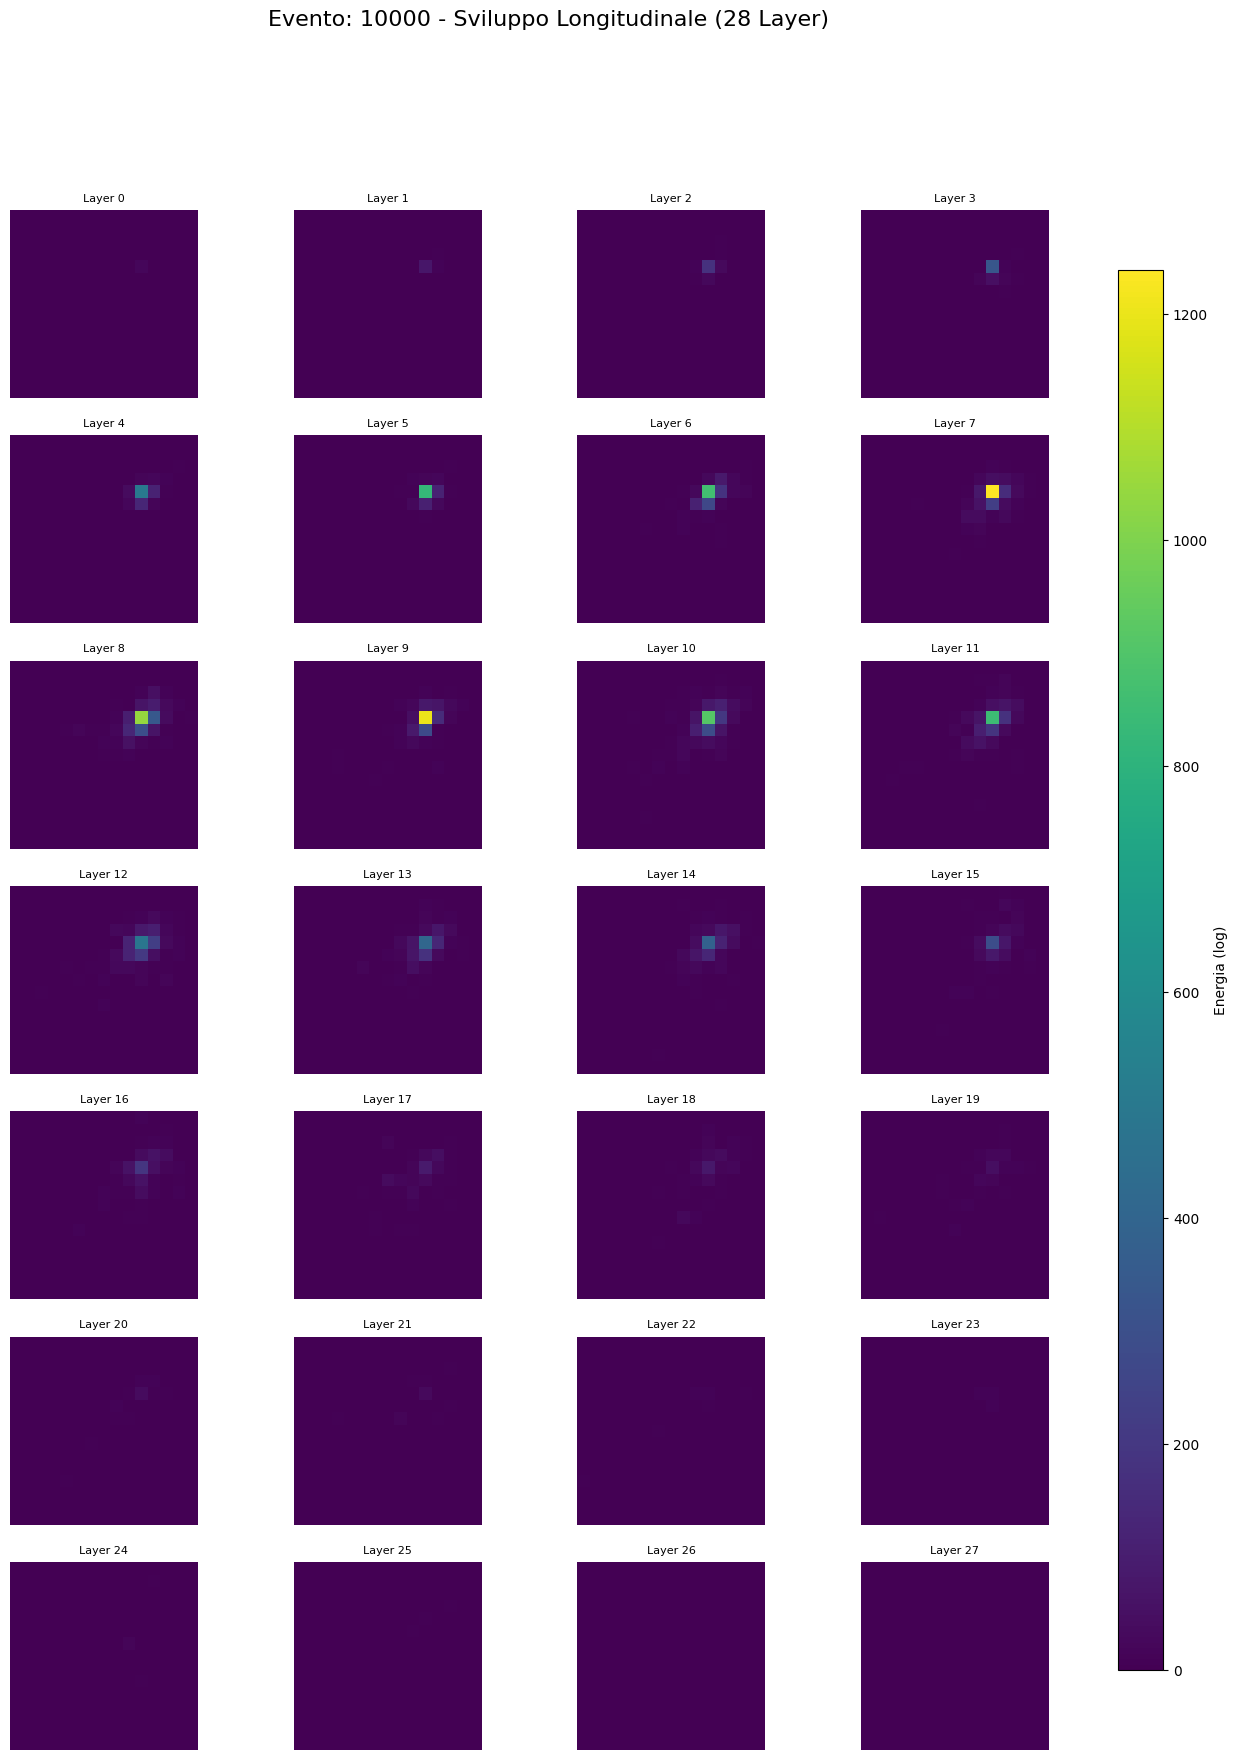

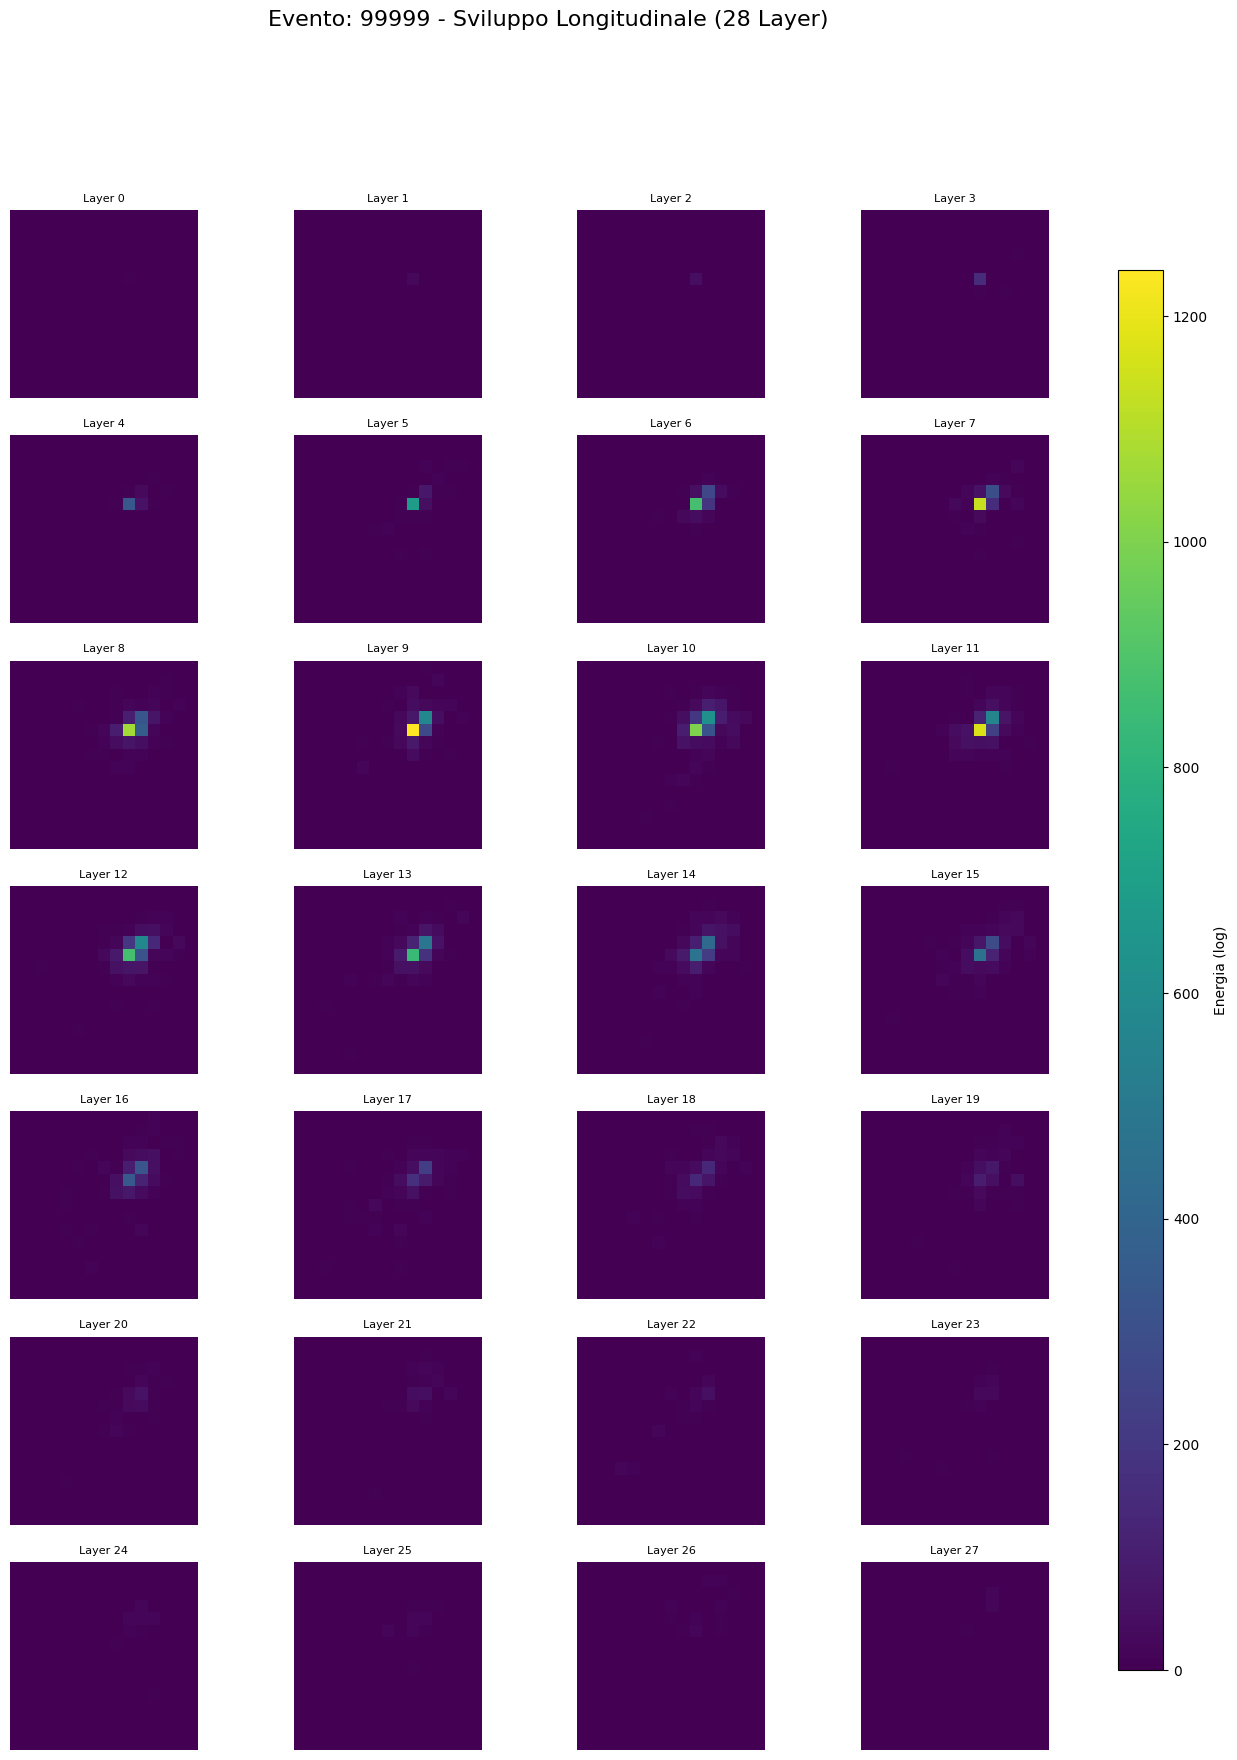

In [ ]:
plot_all_layers_after_transf(dataset, [0, 100, 1000, 10000, 99999])

In [ ]:
import matplotlib.pyplot as plt
import torch
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

In [ ]:
#Logaritmic transformation to scale the energy values, making them more manageable for the neural network

k = 0.0106 #conversion factor MIPs -> GeV
np.log1p(dataset*k, out=dataset)
np.log1p(target_energy, out=target_energy)
print(f"dataset min-max = {dataset.min()}, {dataset.max()}")
print(f"target min-max = {target_energy.min()}, {target_energy.max()}")

dataset min-max = 0.0, 3.851884126663208
target min-max = 2.397916793823242, 5.860785961151123


In [ ]:
class HGCALDataset(Dataset):
    def __init__(self, voxels, targets):
        self.x = torch.from_numpy(voxels).float()
        self.y = torch.from_numpy(targets).float()

        self.x = self.x.unsqueeze(1)

        if self.y.ndim == 1:
            self.y = self.y.unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

hgc_data = HGCALDataset(dataset, target_energy)

In [ ]:
from torch.utils.data import random_split
N = len(hgc_data)
train_size = int(0.7 * N)
val_size   = int(0.15 * N)
test_size  = N - train_size - val_size
g = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(hgc_data, [train_size, val_size, test_size], generator=g)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers= 2)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers= 2)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers= 2)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


#3 conv3d layers, 2 poolings + physical features
class HGCAL_Net(nn.Module):
    def __init__(self, depth=28, max_energy_log=5.8):
        super().__init__()
        self.depth = depth
        self.max_val = max_energy_log


        self.conv1 = nn.Conv3d(1, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)) #To capture single layer pattern (tranverse information)
        self.conv2 = nn.Conv3d(32, 64, kernel_size=(3, 1, 1), padding=(1, 0, 0)) #To capture intra-layer pattern (longitudinal information)
        self.bn2 = nn.BatchNorm3d(64)

        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, padding=(1, 2, 2), dilation=(1, 2, 2))
        self.bn3 = nn.BatchNorm3d(128)
        self.bottleneck = nn.Conv3d(128, 32, kernel_size=1)

        self.spatial_pool = nn.AdaptiveAvgPool3d((2, 4, 4)) #Reducing number of features
        self.global_pool = nn.AdaptiveAvgPool3d(1)

        input_fc_dim = (32 * 2 * 4 * 4) + 32 + 1 + 1 + self.depth + 1

        self.fc = nn.Sequential(
            nn.Linear(input_fc_dim, 256),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        #Physical features exctraction 
        x_lin = torch.expm1(x)
        #Total energy
        g_sum = torch.sum(x_lin.view(x_lin.size(0), -1), dim=1, keepdim=True)
        g_sum_log_norm = torch.log1p(g_sum) / self.max_val

        #Longitudinal profile
        E_z = torch.sum(x_lin, dim=(1, 3, 4))
        E_z_norm = torch.log1p(E_z) / self.max_val

        #Center of gravity
        z_indices = torch.arange(self.depth, device=x.device, dtype=x.dtype)
        z_cg = torch.sum(E_z * z_indices, dim=1, keepdim=True) / (g_sum + 1e-6)
        z_cg_norm = z_cg / self.depth

        #Lateral spread
        lat_spread = torch.std(x_lin, dim=(2, 3, 4)).mean(dim=1, keepdim=True)
        lat_spread_norm = torch.tanh(lat_spread)

        x_c = F.silu(self.conv1(x))
        x_c = F.silu(self.bn2(self.conv2(x_c)))
        x_c = F.silu(self.bn3(self.conv3(x_c)))
        x_c = self.bottleneck(x_c)

        x_spat = self.spatial_pool(x_c).view(x_c.size(0), -1)
        x_glob = self.global_pool(x_c).view(x_c.size(0), -1)

        combined = torch.cat([
            x_spat, x_glob,
            g_sum_log_norm, z_cg_norm, E_z_norm, lat_spread_norm
        ], dim=1)

        return self.fc(combined), g_sum

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
    print('Selected %s' % (device))
else:
    device = 'cpu'
    print('WARNING: using cpu!')

Selected cuda


In [ ]:
model = HGCAL_Net().to(device)
summary(model, input_size=(1, 28, 15, 15))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1       [-1, 32, 28, 15, 15]             320
            Conv3d-2       [-1, 64, 28, 15, 15]           6,208
       BatchNorm3d-3       [-1, 64, 28, 15, 15]             128
            Conv3d-4      [-1, 128, 28, 15, 15]         221,312
       BatchNorm3d-5      [-1, 128, 28, 15, 15]             256
            Conv3d-6       [-1, 32, 28, 15, 15]           4,128
 AdaptiveAvgPool3d-7          [-1, 32, 2, 4, 4]               0
 AdaptiveAvgPool3d-8          [-1, 32, 1, 1, 1]               0
            Linear-9                  [-1, 256]         278,528
             SiLU-10                  [-1, 256]               0
          Dropout-11                  [-1, 256]               0
           Linear-12                  [-1, 128]          32,896
             SiLU-13                  [-1, 128]               0
          Dropout-14                  [

In [ ]:
from tqdm import tqdm

#custom loss, logcosh to handle outlier, weights to focus more on high energies events, which are more affected by leakage (that I want to correct)
#Metric built to evaluate the resolution of the model, which is the ultimate goal of this project
class WeightedLogCoshResolutionLoss(nn.Module):
    def __init__(self, power=0.5, max_rel_err=5.0):
        super().__init__()
        self.power = power
        self.max_rel_err = max_rel_err

    def forward(self, y_pred_log, y_true_log, g_sum):
        y_pred = torch.expm1(torch.clamp(y_pred_log, max=10.0))
        y_true = torch.expm1(y_true_log)
        rel_err = (y_pred - y_true) / (y_true + 1e-7)
        rel_err = torch.clamp(rel_err, min=-1.0, max=self.max_rel_err)

        
        loss_raw = torch.log(torch.cosh(rel_err))
        weights = torch.pow(g_sum + 1.0, self.power)

        return torch.mean(loss_raw * weights)




def train_cnn3d_optimized(model, train_loader, val_loader, num_epochs=50, device='cuda', max_lr=5e-4):


    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=1e-2)
    criterion = WeightedLogCoshResolutionLoss(power=0.5).to(device)

    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=steps_per_epoch,
        epochs=num_epochs,
        pct_start=0.1,
        anneal_strategy='cos'
    )

    train_loss_history = []
    val_loss_history = []
    val_res_history = []

    model.to(device)
    epoch_iter = tqdm(range(num_epochs), desc="Training")

    for epoch in epoch_iter:
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.float().view(-1, 1).to(device)

            optimizer.zero_grad()
            outputs, g_sum = model(inputs)
            loss = criterion(outputs, targets, g_sum)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)
        model.eval()
        val_loss = 0.0
        relative_errors = []

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.float().view(-1, 1).to(device)

                y_pred, _ = model(X_val)
                val_loss += criterion(y_pred, y_val).item()
                y_pred_gev = torch.expm1(y_pred)
                y_val_gev = torch.expm1(y_val)
                rel_err = (y_pred_gev - y_val_gev) / (y_val_gev + 1e-7)
                relative_errors.append(rel_err.cpu())
        avg_val_loss = val_loss / len(val_loader)
        val_loss_history.append(avg_val_loss)

        all_rel_errors = torch.cat(relative_errors)
        current_res = torch.std(all_rel_errors).item()
        val_res_history.append(current_res)
        current_lr = optimizer.param_groups[0]['lr']
        epoch_iter.set_description(f"E{epoch+1} | LR: {current_lr:.2e} | TrainL: {avg_train_loss:.4f} | Res: {current_res:.4f}")

    return train_loss_history, val_loss_history, val_res_history

In [ ]:
train_loss_history, val_loss_history, val_res_history = train_cnn3d_optimized(model, train_loader, val_loader, num_epochs=120, device=device )

model_save_path = "/content/drive/MyDrive/cnn3d_final_model9.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Modello salvato con successo in: {model_save_path}")

E120 | LR: 2.00e-09 | TrainL: 0.0008 | Res: 0.0225: 100%|██████████| 120/120 [2:03:06<00:00, 61.56s/it]

Modello salvato con successo in: /content/drive/MyDrive/cnn3d_final_model9.pth


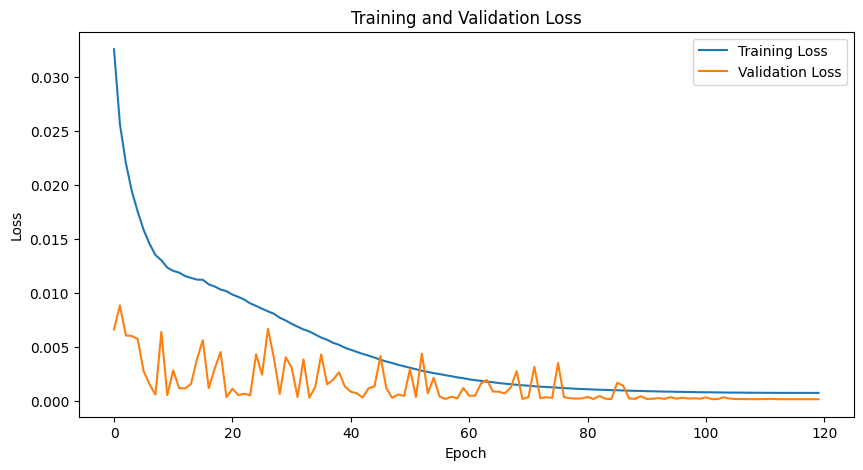

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np

def get_all_predictions(model, loader, device, target_is_log=True):
    model.eval()
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)

            outputs = model(inputs)

            # Trasformiamo in numpy e togliamo le dimensioni extra
            preds = outputs.cpu().numpy().flatten()
            trues = targets.cpu().numpy().flatten()

            # Inversa del logaritmo
            if target_is_log:
                preds = np.expm1(preds)
                trues = np.expm1(trues)

            all_preds.extend(preds)
            all_trues.extend(trues)

    return np.array(all_preds), np.array(all_trues)

# Utilizzo
predizioni_gev, veri_gev = get_all_predictions(model, test_loader, device)

Text(0.5, 1.0, 'Validation')

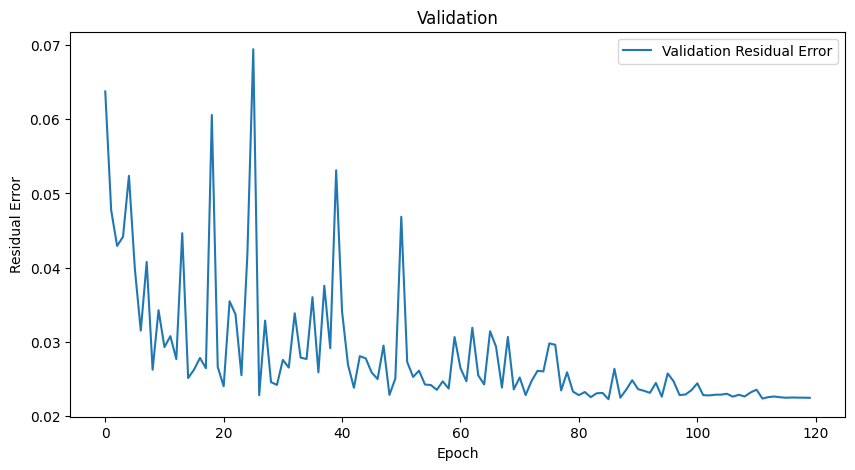

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(val_res_history, label = "Validation Residual Error")
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Residual Error')
plt.title('Validation')